In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor

import os

In [4]:
# pip install torchvision
print('Using PyTorch version:', torch.__version__)
if torch.cuda.is_available():
    print('Using GPU, device name:', torch.cuda.get_device_name(0))
    device = torch.device('cuda')
else:
    print('No GPU found, using CPU instead.') 
    device = torch.device('cpu')


Using PyTorch version: 2.12.1
No GPU found, using CPU instead.


In [7]:
data_dir = os.path.join('/scratch', 'data')
train_dataset = datasets.MNIST('./data', train=True, download=True,transform=ToTensor())
test_dataset = datasets.MNIST('./data', train=False, download=True,transform=ToTensor())

100.0%
100.0%
100.0%
100.0%


In [ ]:
train_lopder = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_lopder = DataLoader(test_dataset, batch_size=32, shuffle=True)


In [16]:
for (data,target) in train_lopder:
    print(data.shape)
    print(target.shape)
    break

torch.Size([32, 1, 28, 28])
torch.Size([32])


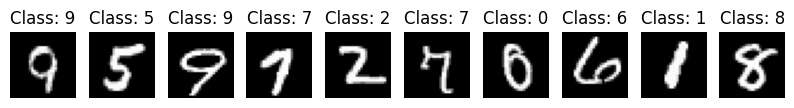

In [18]:
pltsize = 1
plt.figure(figsize=(10*pltsize, pltsize))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.axis('off')
    plt.imshow(data[i,:,:,:].numpy().reshape(28, 28), cmap='gray')
    plt.title(f'Class: {target[i]}')


In [36]:
# train_dataset[0]
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.Sigmoid(),
            nn.Linear(128, 64),
            nn.Sigmoid(),
            nn.Linear(64, 10)
            
        )

    def forward(self, x):
        return self.layers(x)
    
    
model = SimpleMLP().to(device)
print(model)

SimpleMLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): Sigmoid()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): Sigmoid()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [35]:
784*128+ 128*64 + 64*10+ 128+ 64+ 10
# 109184

# GPT 1 : 3 B parameters ( weights and biases)

109386

In [ ]:
# model.parameters()

<generator object Module.parameters at 0x13c7902e0>

In [22]:
# step 1 : Define the loss function
criterion = nn.CrossEntropyLoss()
# step2 : Define the optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [23]:
def correct(output, target):
    predicted_digits = output.argmax(1)                            # pick digit with largest network output
    correct_ones = (predicted_digits == target).type(torch.float)  # 1.0 for correct, 0.0 for incorrect
    return correct_ones.sum().item()                               

In [31]:
def train(data_loader, model, criterion, optimizer):
    model.train()
    num_batches = len(data_loader)
    num_items = len(data_loader.dataset)
    total_loss = 0
    error =[]
    total_correct = 0
    for data, target in data_loader:
        data = data.to(device)
        target = target.to(device)
        output = model(data)
        loss = criterion(output, target)
        error.append(loss.item())
        total_loss +=loss
        total_correct += correct(output, target)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    train_loss = total_loss / num_batches
    accuracy = total_correct / num_items
    print(f'Avg Train loss: {train_loss:.4f}, accuracy: {accuracy:.4f}')
    return error
        
        

In [37]:
%%time

for epoch in range(10):
    print(f'Epoch {epoch+1}')
    train(train_lopder, model, criterion, optimizer)

Epoch 1
Avg Train loss: 2.3568, accuracy: 0.1022
Epoch 2
Avg Train loss: 2.3568, accuracy: 0.1022
Epoch 3
Avg Train loss: 2.3568, accuracy: 0.1022
Epoch 4
Avg Train loss: 2.3568, accuracy: 0.1022
Epoch 5
Avg Train loss: 2.3568, accuracy: 0.1022
Epoch 6
Avg Train loss: 2.3568, accuracy: 0.1022
Epoch 7
Avg Train loss: 2.3568, accuracy: 0.1022
Epoch 8
Avg Train loss: 2.3568, accuracy: 0.1022
Epoch 9
Avg Train loss: 2.3568, accuracy: 0.1022
Epoch 10
Avg Train loss: 2.3568, accuracy: 0.1022
CPU times: user 13.1 s, sys: 2.28 s, total: 15.4 s
Wall time: 15.2 s


In [27]:
def test(test_loader, model, criterion):
    model.eval()

    num_batches = len(test_loader)
    num_items = len(test_loader.dataset)

    test_loss = 0
    total_correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            # Copy data and targets to GPU
            data = data.to(device)
            target = target.to(device)
        
            # Do a forward pass
            output = model(data)
        
            # Calculate the loss
            loss = criterion(output, target)
            test_loss += loss.item()
        
            # Count number of correct digits
            total_correct += correct(output, target)

    test_loss = test_loss/num_batches
    accuracy = total_correct/num_items

    print(f"Testset accuracy: {100*accuracy:>0.1f}%, average loss: {test_loss:>7f}")

In [ ]:
Avg Train loss: 0.5866, accuracy: 0.8636


In [33]:
test(test_lopder, model, criterion)

Testset accuracy: 92.5%, average loss: 0.272519


In [ ]:
# https://github.com/CSCfi/machine-learning-scripts/blob/master/notebooks/pytorch-mnist-mlp.ipynb

In [38]:
# save it as model.pt
torch.save(model.state_dict(), 'model.pt')

In [ ]:
test_lopder

In [ ]:
# save it 
# load it 
model = torch.load('model.pt')
output = model(test_lopder)
